In [1]:
%pip install seaborn
%pip install jinja2

In [2]:
# Importing essential libraries for data analysis and visualization

# pandas: used for loading, cleaning, and analyzing structured data
import pandas as pd

# numpy: provides numerical functions and support for array-based computations
import numpy as np

# seaborn: used for creating attractive statistical plots built on top of matplotlib
import seaborn as sns

# matplotlib.pyplot, plotly.express: provides tools to create plots, charts, and visualizations manually
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

# scipy: used for statistical testing (chi-square test)
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = DeprecationWarning)

In [3]:
# Load dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('customer_journey.csv')

# DATASET STRUCTURE OVERVIEW
# Shape of the dataset (rows × columns)
print("Shape:", df.shape)

# Complete list of column names
print("\nColumns:")
print("=" * 50)
print(df.columns.tolist())
print("=" * 50)

Shape: (12719, 10)

Columns:
['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country', 'ReferralSource', 'TimeOnPage_seconds', 'ItemsInCart', 'Purchased']


In [4]:
# DATA QUALITY CHECK - MISSING VALUES & DATA TYPES

# Count of missing (null) values for each column - beautifully formatted output
print("\n" + "="*60)
print("NULL VALUES SUMMARY")
print("="*60)
print(df.isnull().sum())
print("="*60)


NULL VALUES SUMMARY
SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64


In [5]:
# DATA TYPES SUMMARY

# Data types for each column with enhanced formatting
print("\n" + "="*60)
print("DATA TYPES SUMMARY")
print("="*60)
print(df.dtypes)
print("="*60)


DATA TYPES SUMMARY
SessionID             object
UserID                object
Timestamp             object
PageType              object
DeviceType            object
Country               object
ReferralSource        object
TimeOnPage_seconds     int64
ItemsInCart            int64
Purchased              int64
dtype: object


In [6]:
# BASIC NUMERIC SUMMARY STATISTICS

# Generate comprehensive summary statistics for numeric columns (mean, std, min, max, quartiles)
print("\n" + "="*60)
print("NUMERIC SUMMARY STATISTICS")
print("="*60)
print(df.describe())
print("="*60)


NUMERIC SUMMARY STATISTICS
       TimeOnPage_seconds   ItemsInCart     Purchased
count        12719.000000  12719.000000  12719.000000
mean            97.427707      1.138533      0.397044
std             48.120729      1.689954      0.489304
min             15.000000      0.000000      0.000000
25%             56.000000      0.000000      0.000000
50%             98.000000      0.000000      0.000000
75%            139.000000      2.000000      1.000000
max            180.000000      5.000000      1.000000


In [7]:
# TIMESTAMP EXPLORATION & FEATURE ENGINEERING

# Check original timestamp data type before conversion
print("\nORIGINAL TIMESTAMP INFO")
print("Original Timestamp dtype:", df['Timestamp'].dtype)
print("="*60)

# Convert Timestamp column to proper datetime format for time-based analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(by=['SessionID', 'Timestamp'])

# EXTRACT TIME-BASED FEATURES

print("\nCREATING TIME FEATURES")

# Extract hour of day (0-23) for time-of-day analysis
df['HourOfDay'] = df['Timestamp'].dt.hour

# Extract day of week as readable names (Monday, Tuesday, etc.)
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

# Extract just the date for daily analysis
df['Date'] = df['Timestamp'].dt.date

# Extract month number (1-12) for monthly trends
df['Month'] = df['Timestamp'].dt.month

# Extract month names for readable charts
df['Month_Name'] = df['Timestamp'].dt.month_name()

print("New time-based features created successfully.")
print("="*60)

# Preview the new time features with original timestamp
print("\nNEW TIME FEATURES PREVIEW")
print("="*60)
print(df[['Timestamp', 'HourOfDay', 'DayOfWeek', 'Date', 'Month_Name']].head())
print("="*60)

# DATE RANGE ANALYSIS

# Check the temporal coverage of the dataset to understand analysis period

print("\nDATE RANGE SUMMARY")
print("="*60)
print(f"Number of unique dates: {df['Date'].nunique()}")      # Total distinct days in dataset
print(f"Data starts on: {df['Date'].min()}")                 # Earliest date recorded
print(f"Data ends on: {df['Date'].max()}")                   # Latest date recorded
print("="*60)


ORIGINAL TIMESTAMP INFO
Original Timestamp dtype: object

CREATING TIME FEATURES
New time-based features created successfully.

NEW TIME FEATURES PREVIEW
             Timestamp  HourOfDay  DayOfWeek        Date Month_Name
0  2025-01-20 22:53:34         22     Monday  2025-01-20    January
1  2025-02-26 12:57:10         12  Wednesday  2025-02-26   February
2  2025-02-26 12:59:11         12  Wednesday  2025-02-26   February
20 2025-05-17 22:11:37         22   Saturday  2025-05-17        May
21 2025-05-17 22:13:33         22   Saturday  2025-05-17        May

DATE RANGE SUMMARY
Number of unique dates: 243
Data starts on: 2025-01-01
Data ends on: 2025-08-31


In [8]:
# Funnel Logic Validation
# Check: did sessions actually follow the funnel order, or did some skip steps?

funnel_steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']
funnel_order = {step: i for i, step in enumerate(funnel_steps)}

# For each session, find all funnel steps visited
session_steps = (
    df[df['PageType'].isin(funnel_steps)]
    .groupby('SessionID')['PageType']
    .apply(set)
    .reset_index()
)

# Check for sessions that skipped steps
def find_skipped(steps_visited):
    indices = sorted([funnel_order[s] for s in steps_visited])
    expected = list(range(indices[0], indices[-1] + 1))
    return indices != expected

session_steps['SkippedSteps'] = session_steps['PageType'].apply(find_skipped)

skipped_count = session_steps['SkippedSteps'].sum()
total_sessions = len(session_steps)

print(f"Total sessions: {total_sessions}")
print(f"Sessions that skipped steps: {skipped_count} ({skipped_count/total_sessions:.2%})")
print(f"Sessions with clean funnel path: "
      f"{total_sessions - skipped_count} ({(total_sessions - skipped_count)/total_sessions:.2%})")

Total sessions: 5000
Sessions that skipped steps: 0 (0.00%)
Sessions with clean funnel path: 5000 (100.00%)


In [9]:
# Funnel Step-by-Step Analysis

# Define the correct funnel order
funnel_steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']

# Count unique sessions reaching each funnel step
funnel_df = (
    df.groupby('PageType')['SessionID']
      .nunique()
      .reindex(funnel_steps)
      .reset_index()
)

# Rename columns clearly
funnel_df.columns = ['PageType', 'SessionCount']

# Calculate next step session count
funnel_df['NextStepSessionCount'] = funnel_df['SessionCount'].shift(-1)

# Calculate step-to-step conversion %
funnel_df['To_Next_Step_Conversion_%'] = (
    funnel_df['NextStepSessionCount'] / funnel_df['SessionCount']
) * 100

# Calculate drop count
funnel_df['Drop_Count'] = (
    funnel_df['SessionCount'] - funnel_df['NextStepSessionCount']
)

# Calculate drop %
funnel_df['Drop_%'] = (
    funnel_df['Drop_Count'] / funnel_df['SessionCount']
) * 100

# Calculate overall conversion % from first step
first_step_sessions = funnel_df.loc[0, 'SessionCount']
funnel_df['Overall_Conversion_%'] = (
    funnel_df['SessionCount'] / first_step_sessions
) * 100

# Final step has no next step, so we keep it blank instead of 0
funnel_df.loc[funnel_df.index[-1], ['NextStepSessionCount', 'To_Next_Step_Conversion_%', 'Drop_Count', 'Drop_%']] = np.nan

print("Funnel Step-by-Step Analysis:")

display(
    funnel_df.style.format({
        'To_Next_Step_Conversion_%': '{:.2f}%',
        'Drop_%': '{:.2f}%',
        'Overall_Conversion_%': '{:.2f}%'
    }).format(na_rep='-')
)

Funnel Step-by-Step Analysis:


,PageType,SessionCount,NextStepSessionCount,To_Next_Step_Conversion_%,Drop_Count,Drop_%,Overall_Conversion_%
0,home,5000,3987.000000,79.740000,1013.000000,20.260000,100.000000
1,product_page,3987,1599.000000,40.105342,2388.000000,59.894658,79.740000
2,cart,1599,1123.000000,70.231395,476.000000,29.768605,31.980000
3,checkout,1123,1010.000000,89.937667,113.000000,10.062333,22.460000
4,confirmation,1010,-,-,-,-,20.200000


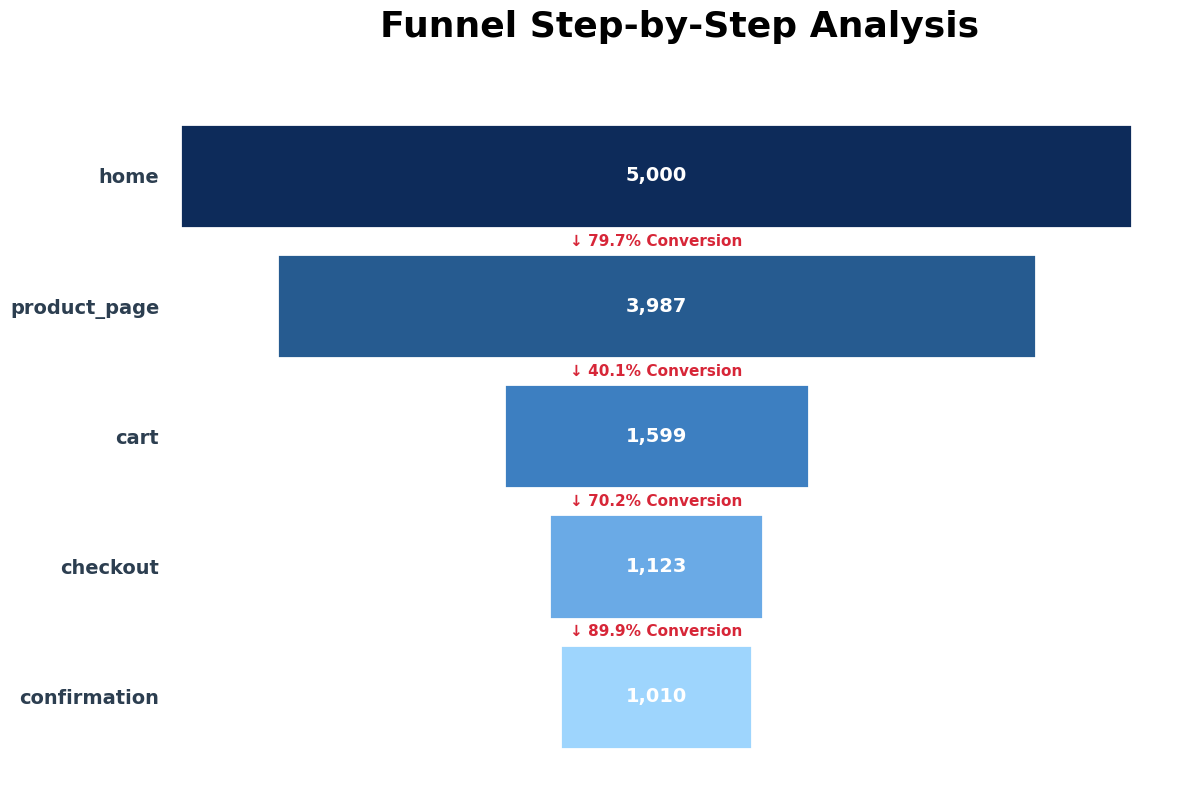

In [10]:
# 1. Data Setup & Centering Logic

funnel_stats = funnel_df[['PageType', 'SessionCount']].copy()
max_sessions = funnel_stats['SessionCount'].max()
funnel_stats['left'] = (max_sessions - funnel_stats['SessionCount']) / 2
funnel_stats = funnel_stats.iloc[::-1].reset_index(drop=True) 

# 2. Setup Figure and Axis (OO Style)
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# 3. Styling Variables
sapphire_colors = ["#9ED5FD", "#6AAAE6", "#3D7FC1", "#265B90", "#0D2B5A"]
font_main = {'family': 'sans-serif', 'weight': 'bold'}

# 4. Draw Bars
bars = ax.barh(funnel_stats['PageType'], funnel_stats['SessionCount'], left=funnel_stats['left'], 
               color=sapphire_colors, edgecolor='white', linewidth=2)

# 5. Add Value Labels (Inside Bars)
for i, row in funnel_stats.iterrows():
    ax.text(max_sessions/2, i, f"{int(row['SessionCount']):,}", 
            va='center', ha='center', color='white', 
            fontsize=14, fontdict=font_main)

# 6. Add Conversion Labels (Between Bars)
for i in range(len(funnel_stats) - 1, 0, -1):
    curr_val = funnel_stats.loc[i, 'SessionCount']
    next_val = funnel_stats.loc[i-1, 'SessionCount']
    conv = (next_val / curr_val) * 100
    
    ax.text(max_sessions/2, i - 0.5, f"↓ {conv:.1f}% Conversion", 
            ha='center', va='center', fontsize=11, color='#D72638', 
            fontdict=font_main,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=2))

# 7. Final Polish using 'ax' methods
ax.set_title('Funnel Step-by-Step Analysis', fontsize=26, pad=40, fontdict=font_main)

# Hide clutter
ax.set_xticks([])
ax.set_xlabel('')
ax.grid(False)

# Remove all spines
for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_visible(False)

# Format Y-axis tick labels
ax.tick_params(axis='y', labelsize=14, length=0, pad=15)
for label in ax.get_yticklabels():
    label.set_fontfamily('sans-serif')
    label.set_weight('bold')
    label.set_color('#2C3E50')

# 8. Export and Display
fig.tight_layout()
fig.savefig("01_funnel_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Device-wise Funnel Analysis

# Define funnel order
funnel_steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']

# Count unique sessions by DeviceType and PageType
device_funnel = (
    df.groupby(['DeviceType', 'PageType'])['SessionID']
      .nunique()
      .reset_index(name='SessionCount')
)

# Keep funnel steps in correct order
device_funnel['PageType'] = pd.Categorical(
    device_funnel['PageType'],
    categories=funnel_steps,
    ordered=True
)

device_funnel = device_funnel.sort_values(['DeviceType', 'PageType'])

# Pivot to get stages as rows and devices as columns
device_funnel_pivot = (
    device_funnel.pivot(index='PageType', columns='DeviceType', values='SessionCount')
    .reindex(funnel_steps)
)

print("Device-wise Funnel Session Counts:")
display(device_funnel_pivot)

# Step-to-step conversion by device
device_step_conversion = device_funnel_pivot.shift(-1) / device_funnel_pivot * 100

# Overall conversion from home by device
device_overall_conversion = device_funnel_pivot / device_funnel_pivot.loc['home'] * 100

# Drop count by device
device_drop_count = device_funnel_pivot - device_funnel_pivot.shift(-1)

# Drop % by device
device_drop_percent = device_drop_count / device_funnel_pivot * 100

# Final step has no next step, so keep it blank
device_step_conversion.loc['confirmation'] = np.nan
device_drop_count.loc['confirmation'] = np.nan
device_drop_percent.loc['confirmation'] = np.nan

print("Device-wise Step-to-Step Conversion (%):")
display(device_step_conversion.style.format("{:.2f}%").format(na_rep='-'))

print("Device-wise Drop Count:")
display(device_drop_count.style.format("{:.0f}").format(na_rep='-'))

print("Device-wise Drop Percentage (%):")
display(device_drop_percent.style.format("{:.2f}%").format(na_rep='-'))

print("Device-wise Overall Conversion from Home (%):")
display(device_overall_conversion.style.format("{:.2f}%"))

Device-wise Funnel Session Counts:


DeviceType,Desktop,Mobile,Tablet
PageType,,,
home,1666,1671,1663
product_page,1321,1342,1324
cart,529,537,533
checkout,385,369,369
confirmation,339,337,334


Device-wise Step-to-Step Conversion (%):


DeviceType,Desktop,Mobile,Tablet
PageType,,,
home,79.291717,80.311191,79.615153
product_page,40.045420,40.014903,40.256798
cart,72.778828,68.715084,69.230769
checkout,88.051948,91.327913,90.514905
confirmation,-,-,-


Device-wise Drop Count:


DeviceType,Desktop,Mobile,Tablet
PageType,,,
home,345.000000,329.000000,339.000000
product_page,792.000000,805.000000,791.000000
cart,144.000000,168.000000,164.000000
checkout,46.000000,32.000000,35.000000
confirmation,-,-,-


Device-wise Drop Percentage (%):


DeviceType,Desktop,Mobile,Tablet
PageType,,,
home,20.708283,19.688809,20.384847
product_page,59.954580,59.985097,59.743202
cart,27.221172,31.284916,30.769231
checkout,11.948052,8.672087,9.485095
confirmation,-,-,-


Device-wise Overall Conversion from Home (%):


DeviceType,Desktop,Mobile,Tablet
PageType,,,
home,100.00%,100.00%,100.00%
product_page,79.29%,80.31%,79.62%
cart,31.75%,32.14%,32.05%
checkout,23.11%,22.08%,22.19%
confirmation,20.35%,20.17%,20.08%


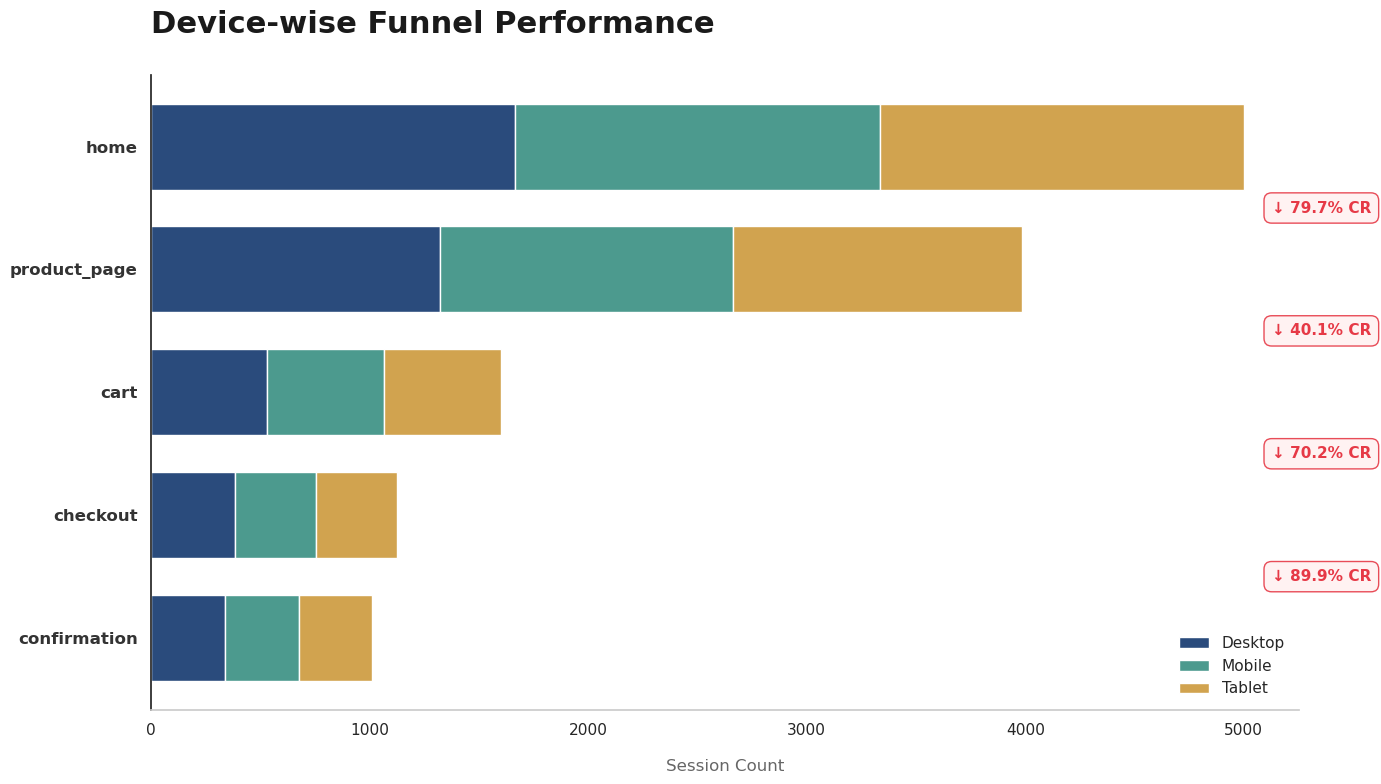

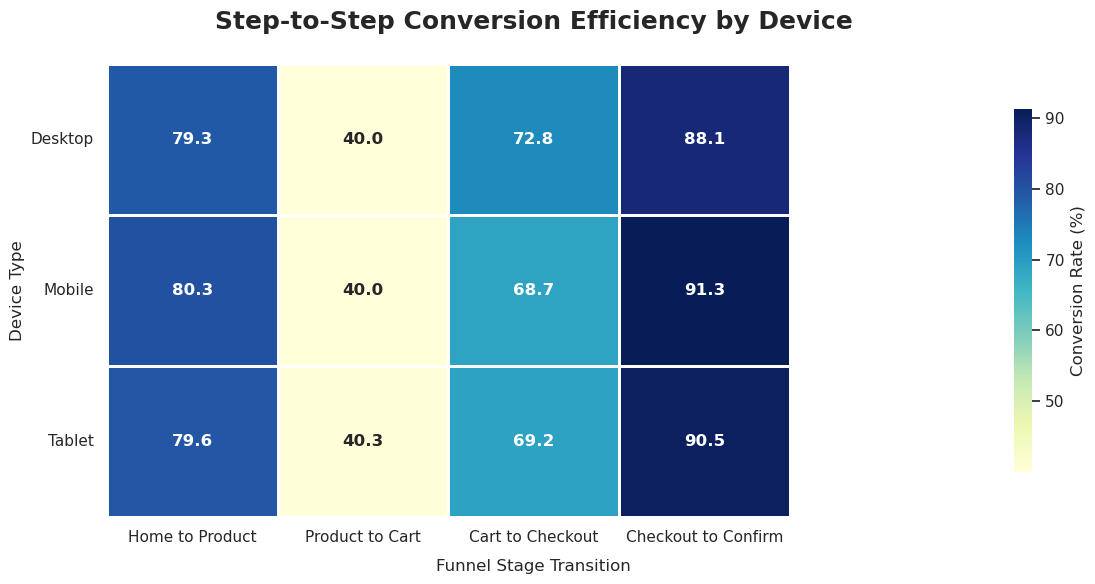

In [12]:
# Updated: Set theme with compatible font handling
sns.set_theme(style="white", rc={"font.family": "sans-serif"})

# Define a professional color palette
colors = {'Desktop': '#2A4B7C', 'Mobile': '#4C9A8E', 'Tablet': '#D1A34F'}

# ---------------------------------------------------------
# 1. Stacked Horizontal Funnel Bars (Sessions)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# Data Setup (assuming device_funnel_pivot and funnel_steps are defined)
y_pos = np.arange(len(funnel_steps))
bottom = np.zeros(len(funnel_steps))
total_widths = device_funnel_pivot.sum(axis=1).values

# Plotting Bars
for device in device_funnel_pivot.columns:
    vals = device_funnel_pivot[device].values
    ax.barh(y_pos, vals, left=bottom, label=device, 
            color=colors.get(device, '#808080'), height=0.7, 
            edgecolor='white', linewidth=1)
    bottom += vals

# Styling Axes
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_steps, fontsize=12, fontweight='bold', color='#333333')
ax.invert_yaxis()  # Logical funnel flow: Top to Bottom
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.set_xlabel('Session Count', fontsize=12, labelpad=15, color='#666666')

# Conversion labels (Right-side badges)
max_val = total_widths.max()
for i in range(len(funnel_steps)-1):
    total_curr = total_widths[i]
    total_next = total_widths[i+1]
    conv = (total_next / total_curr) * 100
    
    # Placing conversion rate badge between the steps
    ax.annotate(f'↓ {conv:.1f}% CR', 
                xy=(max_val, i + 0.5), 
                xytext=(20, 0), textcoords='offset points',
                ha='left', va='center', fontsize=11, fontweight='bold',
                color='#E63946', 
                bbox=dict(boxstyle='round,pad=0.5', fc='#FFF1F1', ec='#E63946', alpha=0.9))

# Title and Legend
plt.title('Device-wise Funnel Performance', fontsize=22, fontweight='bold', 
          pad=30, loc='left', color='#1A1A1A')
ax.legend(frameon=False, loc='lower right', fontsize=11)

plt.tight_layout()

# Save and Show
plt.savefig('02_device_funnel.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 2. Step Conversion Heatmap (Seaborn)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
# Create specific labels for the transitions
transition_labels = ['Home to Product', 'Product to Cart', 'Cart to Checkout', 'Checkout to Confirm']

# Plotting Heatmap with spacing and modern color ramp
ax = sns.heatmap(device_step_conversion.T,
                 xticklabels=transition_labels,
                 annot=True, 
                 fmt='.1f', 
                 cmap='YlGnBu', 
                 linewidths=2, 
                 cbar_kws={'label': 'Conversion Rate (%)', 'shrink': .8},
                 annot_kws={"size": 12, "weight": "bold"})

# Formatting
plt.title('Step-to-Step Conversion Efficiency by Device', fontsize=18, 
          fontweight='bold', pad=25, loc='center')
plt.xlabel('Funnel Stage Transition', fontsize=12, labelpad=10)
plt.ylabel('Device Type', fontsize=12)

# Clean up tick rotation
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# Save and Show
plt.savefig('03_device_conversions_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Create session-level data
session_device = df.groupby('SessionID').agg(
    Device=('DeviceType', 'first'),
    Purchased=('Purchased', 'max')
).reset_index()

# Build contingency table
contingency = pd.crosstab(session_device['Device'], session_device['Purchased'])

# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-Square Test: Device Type vs Conversion")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference exists between devices.")
else:
    print("\nResult: No statistically significant difference between devices.")

Chi-Square Test: Device Type vs Conversion
Chi-Square Statistic: 0.0376
P-Value: 0.9814
Degrees of Freedom: 2

Result: No statistically significant difference between devices.


In [14]:
# Time Spent in Funnel (Session Duration Analysis)

# Step 1: Calculate session-level start time, end time, and total duration
session_time = (
    df.groupby('SessionID')['Timestamp']
      .agg(SessionStart='min', SessionEnd='max')
      .reset_index()
)

session_time['SessionDuration_seconds'] = (
    session_time['SessionEnd'] - session_time['SessionStart']
).dt.total_seconds()

# Step 2: Create session-level purchase flag
# If any row in a session has Purchased = 1, mark the whole session as converted
session_purchase = (
    df.groupby('SessionID')['Purchased']
      .max()
      .reset_index()
      .rename(columns={'Purchased': 'SessionPurchased'})
)

# Step 3: Merge session duration with session purchase flag
session_summary = pd.merge(session_time, session_purchase, on='SessionID', how='left')

# Step 4: Get average time to confirmation for converted sessions only
avg_time_to_conv = (
    session_summary.loc[session_summary['SessionPurchased'] == 1, 'SessionDuration_seconds']
    .mean()
)

print(f"Average Time from First Page to Confirmation (for converters): {avg_time_to_conv:.2f} seconds")

# Step 5: Compare average session duration for converted vs non-converted sessions
avg_duration_comparison = (
    session_summary.groupby('SessionPurchased')['SessionDuration_seconds']
    .mean()
    .reset_index()
)

# Optional: rename values for readability
avg_duration_comparison['SessionPurchased'] = avg_duration_comparison['SessionPurchased'].map({
    0: 'No Purchase',
    1: 'Purchase'
})

print("\nAverage Session Duration Comparison:")
display(avg_duration_comparison)

# Optional: extra summary for deeper understanding
duration_summary = (
    session_summary.groupby('SessionPurchased')['SessionDuration_seconds']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

duration_summary['SessionPurchased'] = duration_summary['SessionPurchased'].map({
    0: 'No Purchase',
    1: 'Purchase'
})

print("\nSession Duration Summary:")
display(duration_summary)

Average Time from First Page to Confirmation (for converters): 388.24 seconds

Average Session Duration Comparison:


,SessionPurchased,SessionDuration_seconds
0,No Purchase,89.751629
1,Purchase,388.237624



Session Duration Summary:


,SessionPurchased,count,mean,median,min,max
0,No Purchase,3990,89.751629,81.0,0.0,468.0
1,Purchase,1010,388.237624,389.0,117.0,668.0


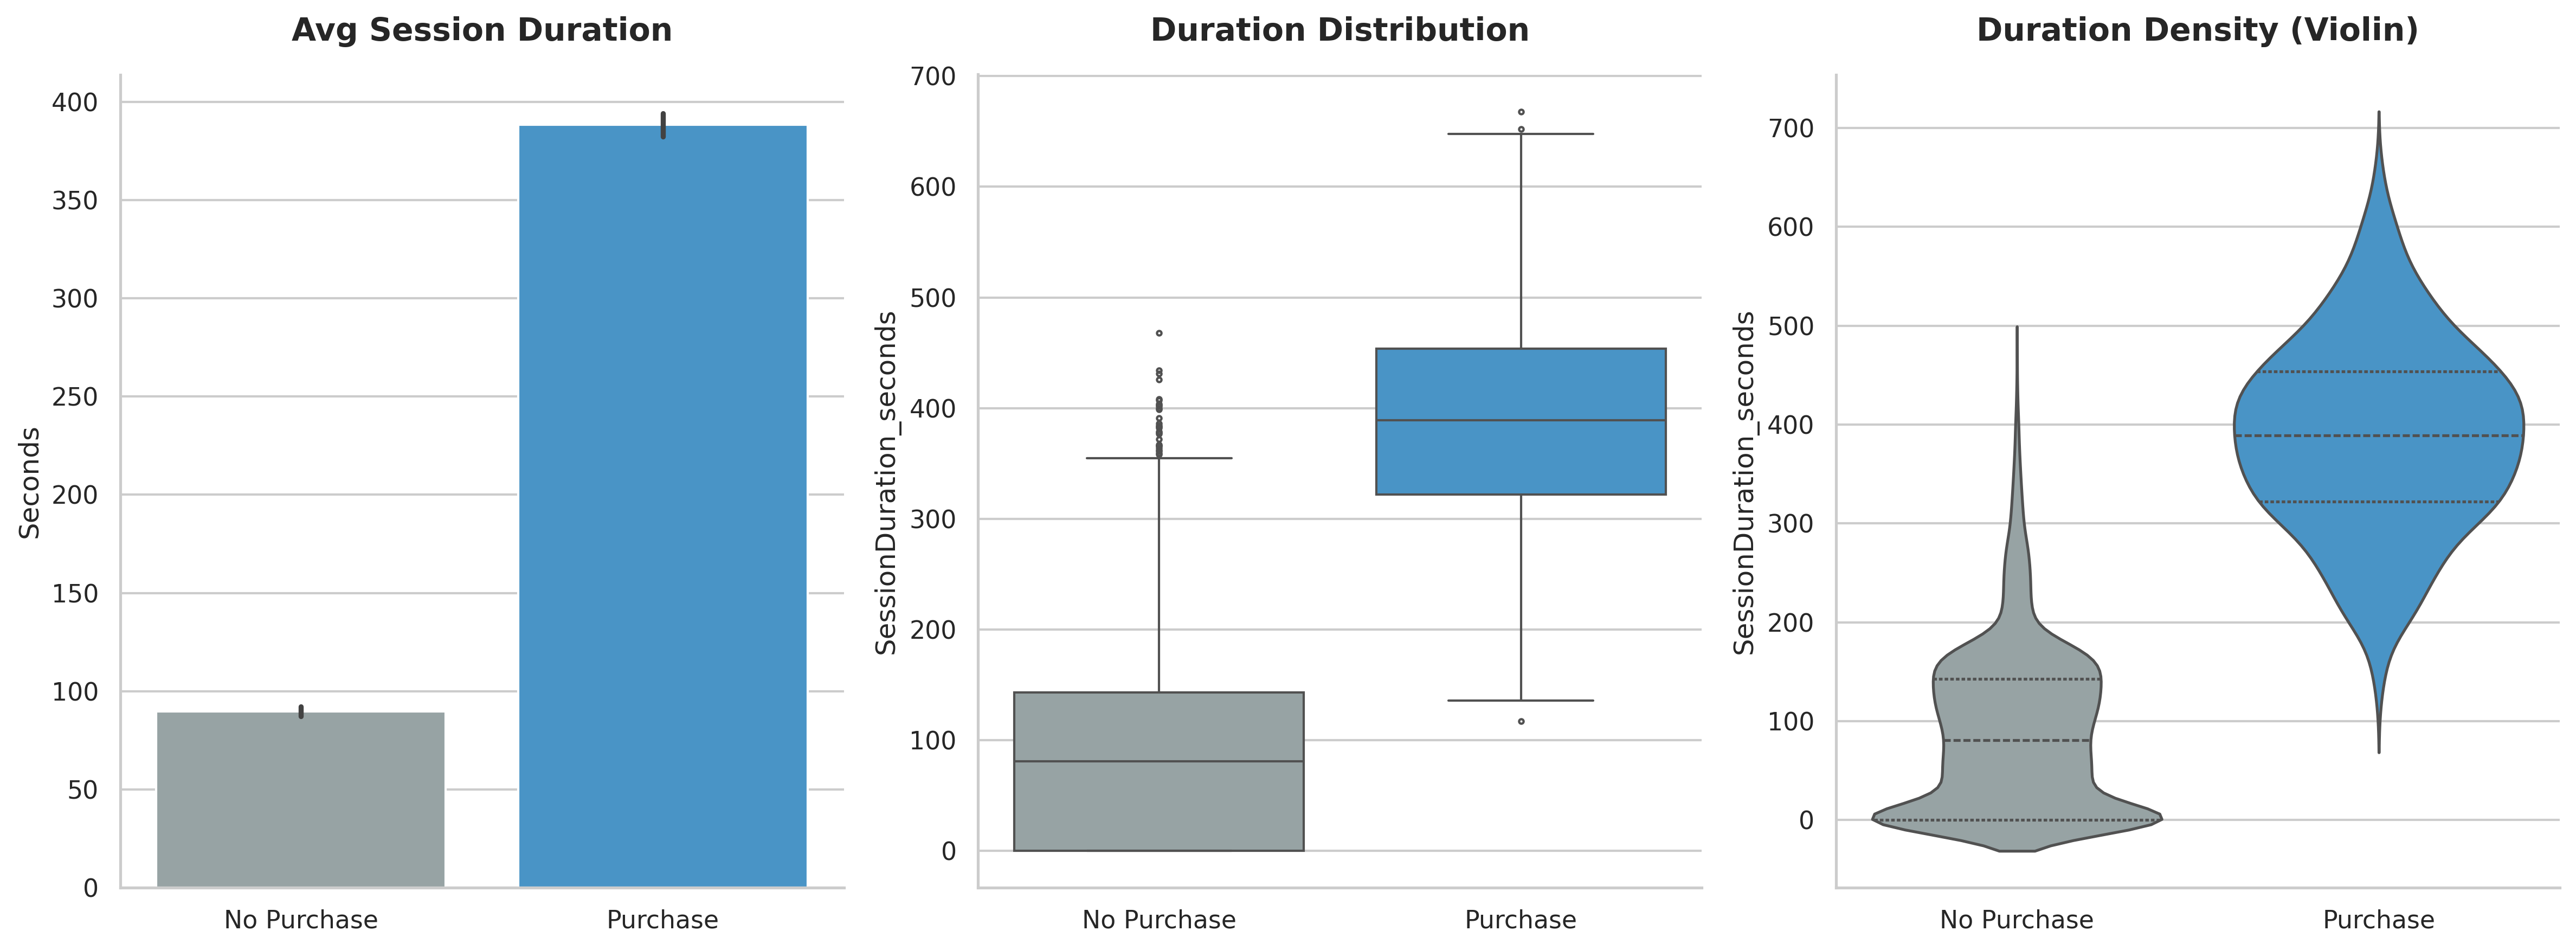

In [15]:
# Set a clean, professional style
# Note: Adding dpi=300 here makes the on-screen plot high-res too
sns.set_theme(style="whitegrid", palette="muted")
labels = ['No Purchase', 'Purchase']
colors = ["#95a5a6", "#3498db"] 

# Create the figure
fig, ax = plt.subplots(1, 3, figsize=(16, 6), dpi=300)

# 1. Bar Plot
sns.barplot(
    data=session_summary, 
    x='SessionPurchased', 
    y='SessionDuration_seconds', 
    ax=ax[0], 
    palette=colors,
    hue='SessionPurchased'
)
ax[0].set_title('Avg Session Duration', fontsize=14, fontweight='bold', pad=15)
ax[0].set_ylabel('Seconds', fontsize=12)

# 2. Box Plot
sns.boxplot(
    data=session_summary, 
    x='SessionPurchased', 
    y='SessionDuration_seconds', 
    ax=ax[1], 
    palette=colors,
    hue='SessionPurchased',
    fliersize=2
)
ax[1].set_title('Duration Distribution', fontsize=14, fontweight='bold', pad=15)

# 3. Violin Plot
sns.violinplot(
    data=session_summary, 
    x='SessionPurchased', 
    y='SessionDuration_seconds', 
    ax=ax[2], 
    palette=colors,
    hue='SessionPurchased',
    inner="quart"
)
ax[2].set_title('Duration Density (Violin)', fontsize=14, fontweight='bold', pad=15)

# General Cleanup for all subplots
for a in ax:
    a.set_xticklabels(labels)
    a.set_xlabel('') 
    
    leg = a.get_legend()
    if leg:
        leg.remove()
        
    sns.despine(ax=a)

plt.tight_layout()

# --- HIGH-END EXPORT CODE ---
# PNG is great for slides/docs; PDF/SVG is best for infinite scaling (vector)
fig.savefig("04_session_analysis_highres.png", dpi=300, bbox_inches='tight')
# fig.savefig("session_analysis_vector.svg", bbox_inches='tight') 

plt.show()

In [16]:
# Product Page Time Analysis (Corrected)

# Create session-level purchase flag
session_purchase = df.groupby('SessionID')['Purchased'].max().reset_index()

# Merge back
df_merged = df.merge(session_purchase, on='SessionID', suffixes=('', '_Session'))

# Filter only product page
product_page_df = df_merged[df_merged['PageType'] == 'product_page']

# Aggregate
product_time_summary = product_page_df.groupby('Purchased_Session')['TimeOnPage_seconds'].agg(
    avg_time='mean',
    median_time='median',
    count='count'
).reset_index()

# Rename
product_time_summary['Purchased_Session'] = product_time_summary['Purchased_Session'].map({
    0: 'Non-Buyer',
    1: 'Buyer'
})

print("Product Page Time Analysis:")
display(product_time_summary)

Product Page Time Analysis:


,Purchased_Session,avg_time,median_time,count
0,Non-Buyer,97.427612,99.0,2977
1,Buyer,95.965347,96.5,1010


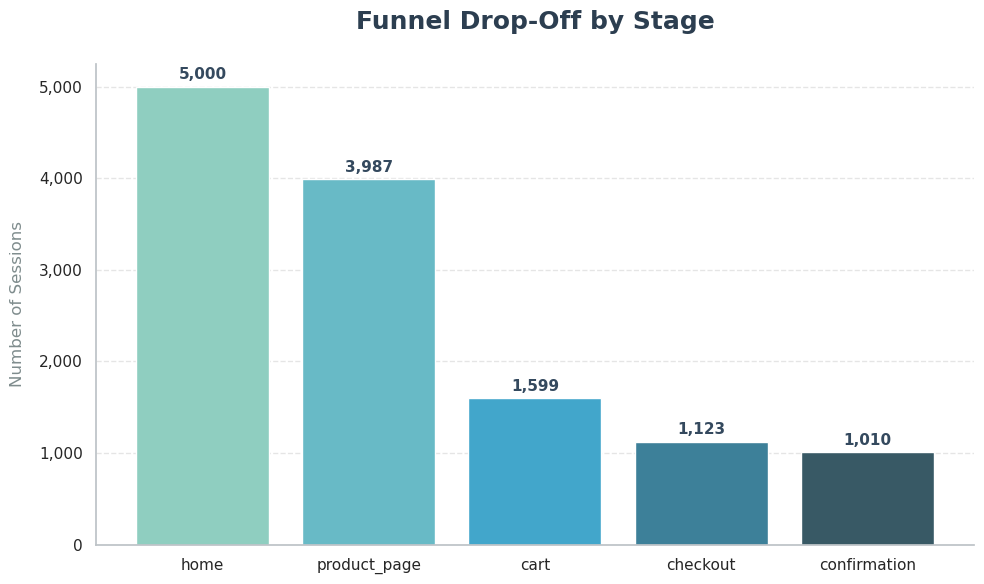

In [17]:
# 1. Theme & Color Palette
sns.set_theme(style="white")  # Clean white background
# Using a custom gradient from light grey to a strong corporate blue/teal
colors = sns.color_palette("GnBu_d", len(funnel_df)) 

# 2. Setup Figure and Axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 3. Create Bar Chart
bars = ax.bar(
    funnel_df['PageType'], 
    funnel_df['SessionCount'], 
    color=colors,
    width=0.8
)

# 4. Title and Labels
ax.set_title("Funnel Drop-Off by Stage", fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')
ax.set_ylabel("Number of Sessions", fontsize=12, color='#7f8c8d', labelpad=10)

# 5. Add Value Labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + (funnel_df['SessionCount'].max() * 0.01),
        f'{int(height):,}',
        ha='center', va='bottom', 
        fontsize=11, fontweight='bold', color='#34495e'
    )

# 6. Formatting & Cleanup
# Fixes the NameError by using mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Modernize the "look" by removing unnecessary lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Add subtle horizontal gridlines
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.2)

# Adjust layout
plt.tight_layout()

# 7. High-End Export
# 300 DPI is the standard for high-quality print/presentations
fig.savefig('05_funnel_analysis_premium.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

In [18]:
# Items in Cart Analysis (Session Level)

# Step 1: Get max items in cart per session
session_items = (
    df.groupby('SessionID')['ItemsInCart']
      .max()
      .reset_index()
      .rename(columns={'ItemsInCart': 'MaxItemsInCart'})
)

# Step 2: Get session-level purchase flag
session_purchase = (
    df.groupby('SessionID')['Purchased']
      .max()
      .reset_index()
      .rename(columns={'Purchased': 'SessionPurchased'})
)

# Step 3: Merge
items_summary = pd.merge(session_items, session_purchase, on='SessionID')

# Step 4: Calculate conversion rate
items_conv = (
    items_summary.groupby('MaxItemsInCart')['SessionPurchased']
    .mean()
    .reset_index()
)

print("Conversion Rate by Items in Cart (Session Level):")
display(items_conv.style.format({'SessionPurchased': '{:.2%}'}))

Conversion Rate by Items in Cart (Session Level):


,MaxItemsInCart,SessionPurchased
0,0,0.00%
1,1,37.68%
2,2,34.62%
3,3,38.17%
4,4,31.19%
5,5,30.95%


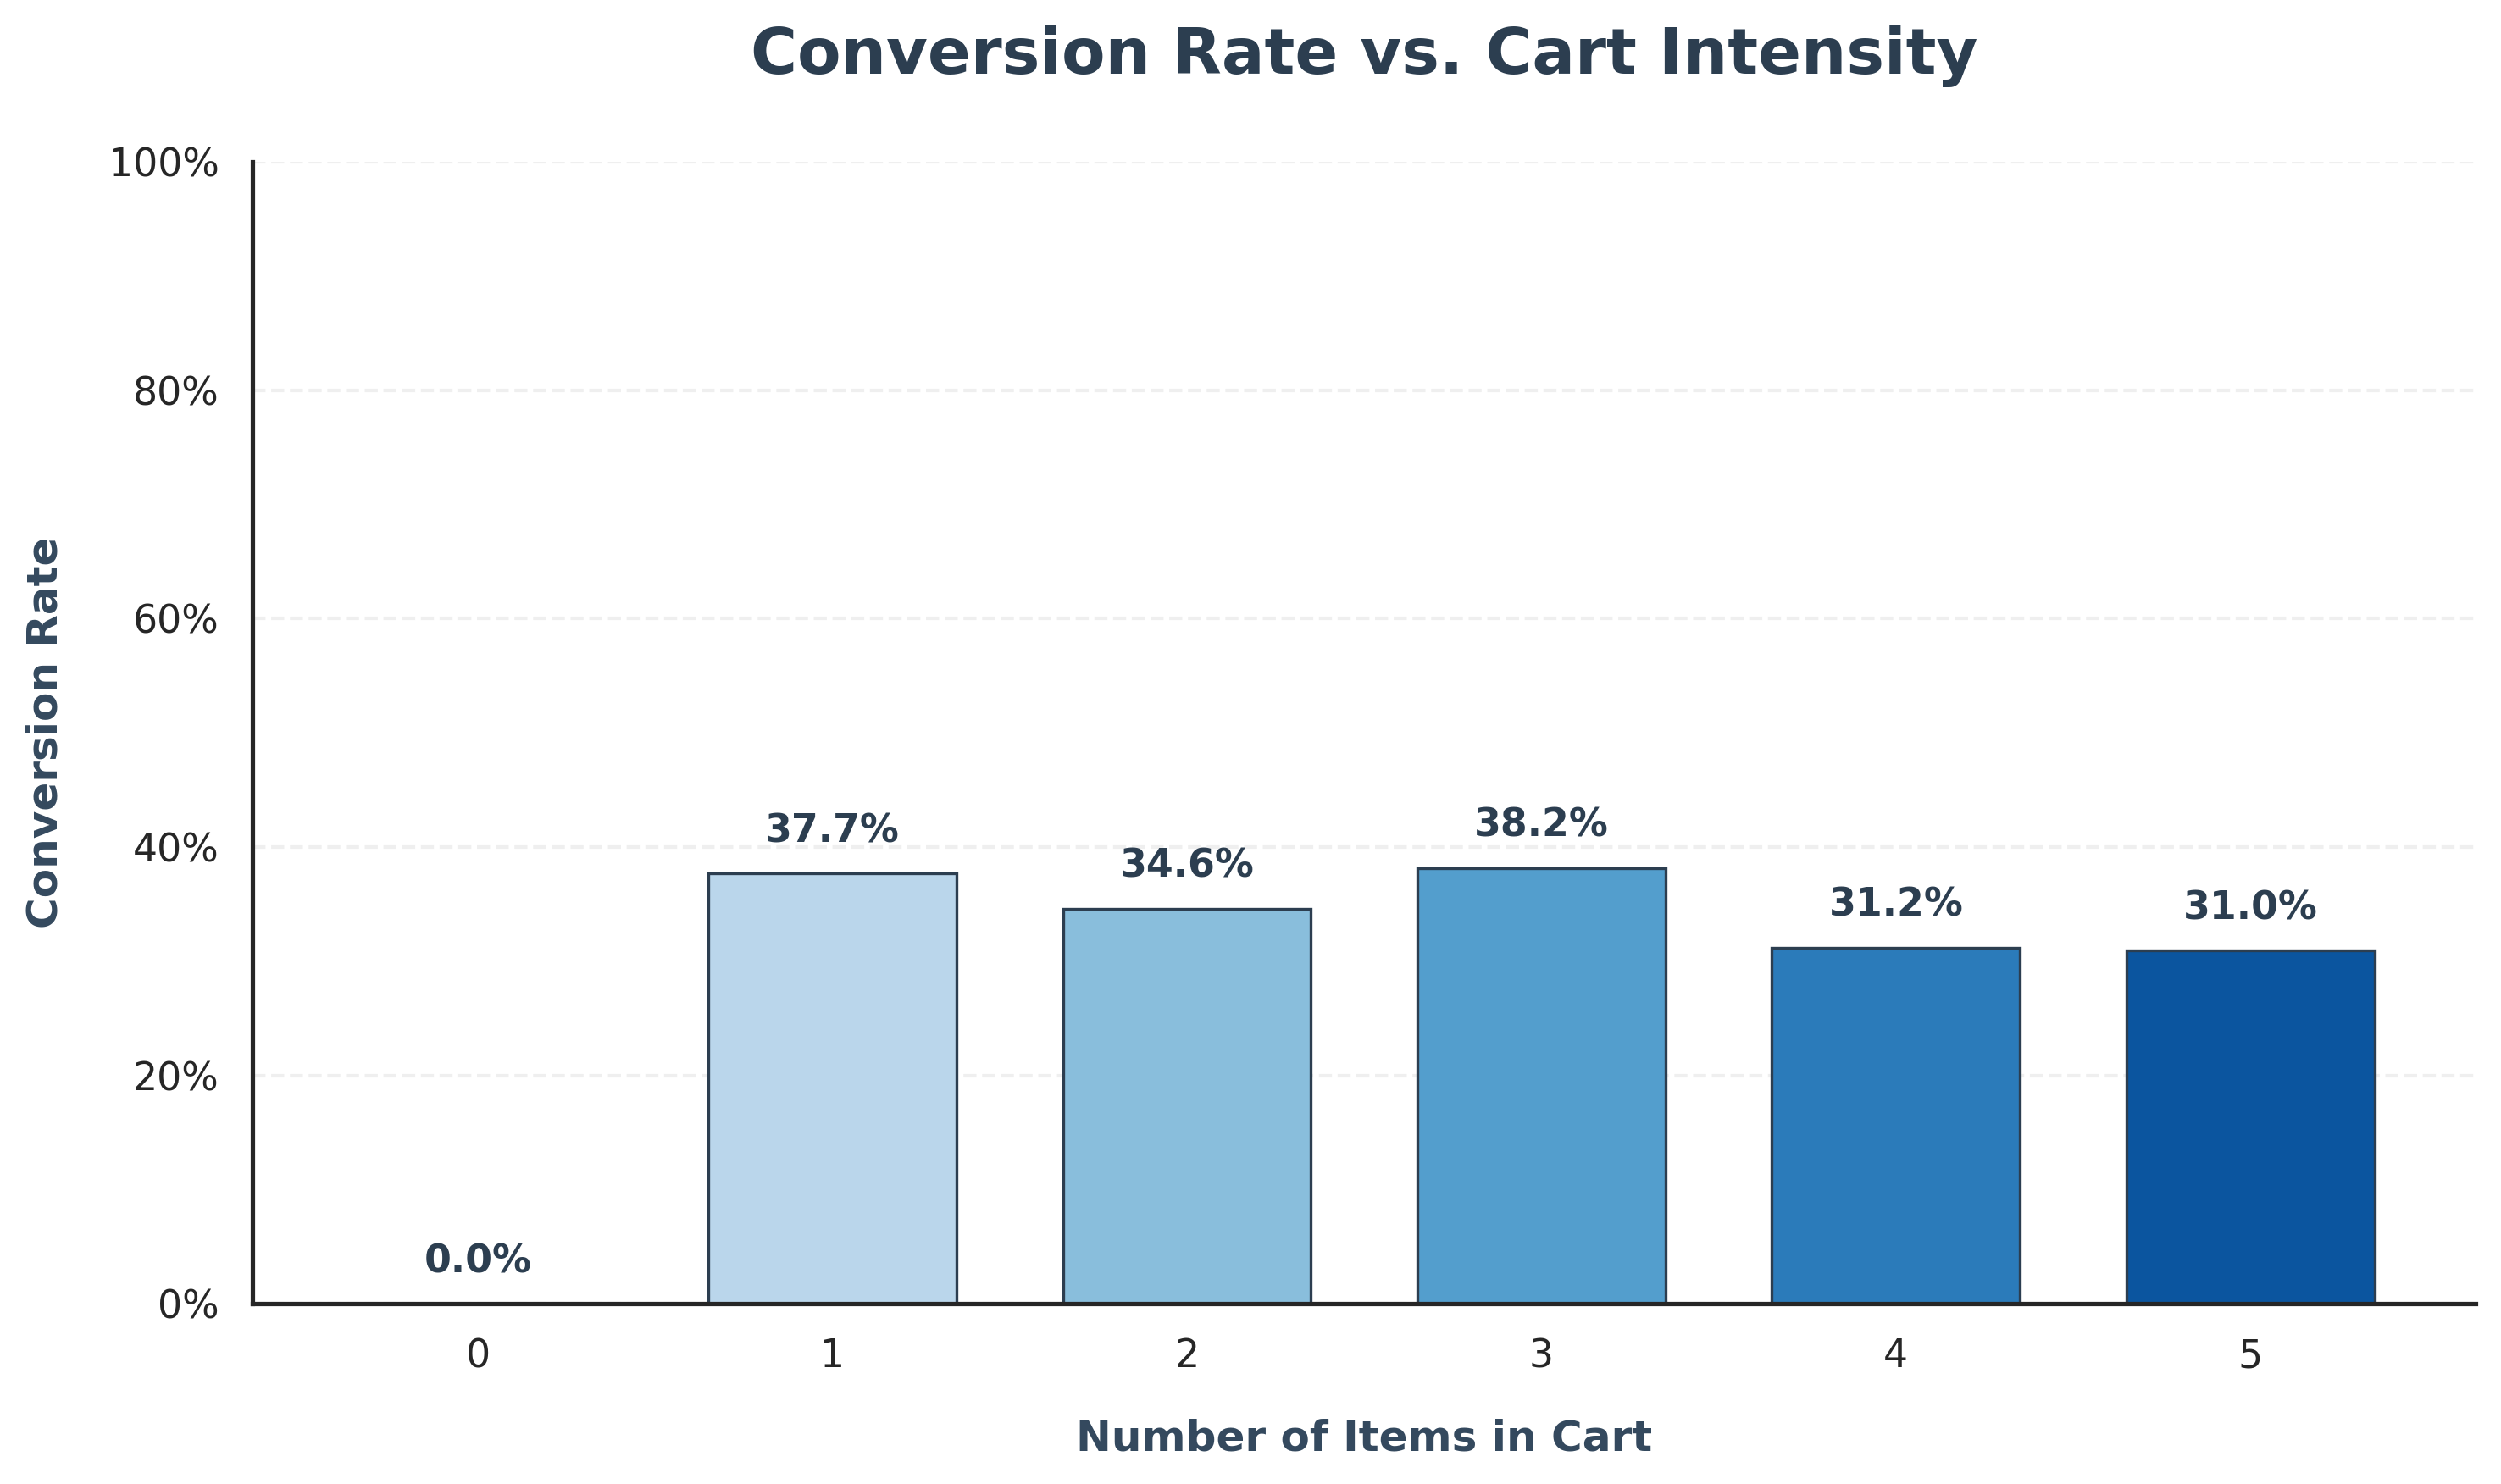

In [19]:
# 1. Setup Data & Aesthetics
# Assuming items_conv is your DataFrame
sns.set_theme(style="white")
# Creating a gradient palette based on the conversion values
colors = sns.color_palette("Blues", len(items_conv))

# 2. Create Figure and Axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Create Bar Plot
bars = ax.bar(
    items_conv['MaxItemsInCart'], 
    items_conv['SessionPurchased'], 
    color=colors,
    edgecolor='#2c3e50',
    linewidth=0.8,
    width=0.7
)

# 4. Titles and Labels
ax.set_title('Conversion Rate vs. Cart Intensity', fontsize=18, fontweight='bold', pad=25, loc='Center', color='#2c3e50')
ax.set_xlabel('Number of Items in Cart', fontsize=12, fontweight='bold', labelpad=12, color='#34495e')
ax.set_ylabel('Conversion Rate', fontsize=12, fontweight='bold', labelpad=12, color='#34495e')

# 5. Formatting Y-Axis as percentage
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 6. Add Percentage Labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.02, 
        f'{height:.1%}', 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='#2c3e50'
    )

# 7. Final Polish
# Remove top and right spines
sns.despine(ax=ax)

# Add subtle horizontal gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Ensure X-axis shows all integer ticks (avoiding 0.5, 1.5, etc.)
ax.set_xticks(items_conv['MaxItemsInCart'])

# 8. High-End Export
plt.tight_layout()
fig.savefig("06_conversion_rate_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Calculate session-level conversion by referral source
ref_conv = (
    df.groupby('ReferralSource')['Purchased']
      .mean()
      .reset_index()
      .sort_values('Purchased', ascending=False)
)

# Display clean table
print("Conversion Rate by Referral Source:")
display(ref_conv.style.format({'Purchased': '{:.2%}'}))

Conversion Rate by Referral Source:


,ReferralSource,Purchased
2,Google,41.92%
0,Direct,39.35%
1,Email,39.07%
3,Social Media,38.36%


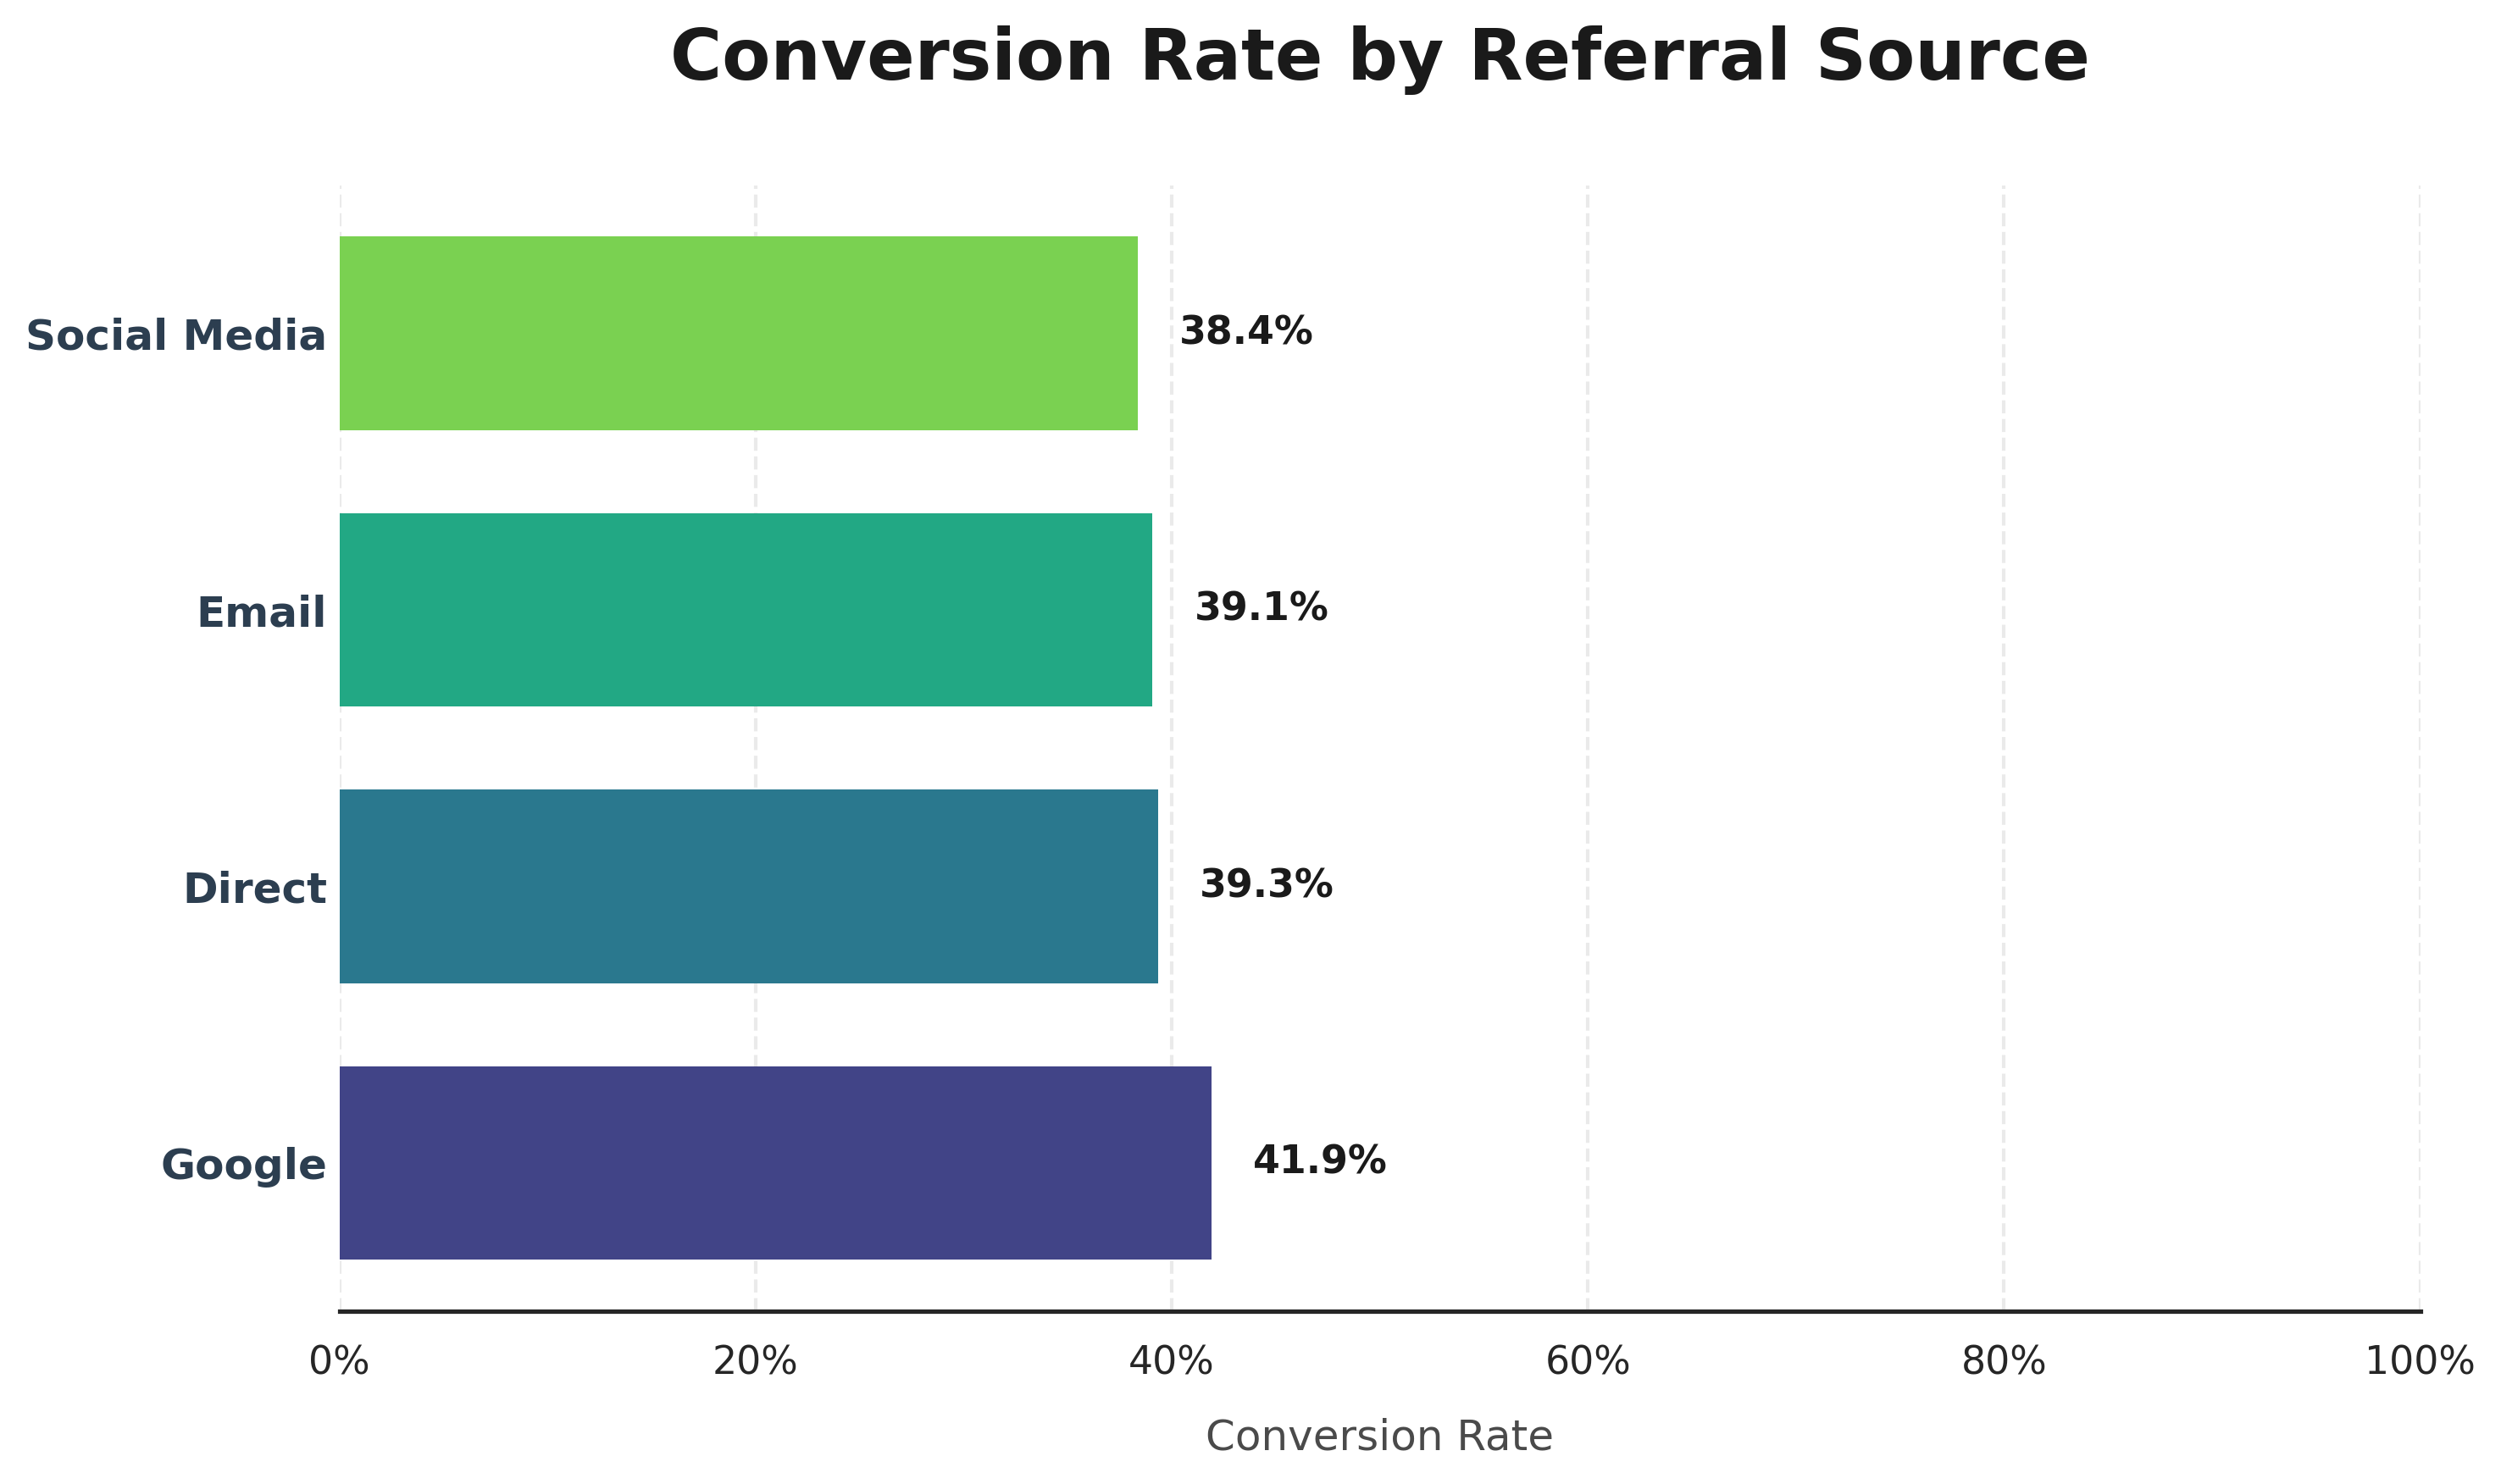

In [21]:
# 1. Setup Data & Aesthetics
sns.set_theme(style="white")
# Creating a vibrant but professional color palette
palette = sns.color_palette("viridis", len(ref_conv))

# 2. Create Figure and Axis (OO Style)
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Create Horizontal Bar Plot
# Horizontal bars are better for categorical labels like 'ReferralSource'
bars = ax.barh(
    ref_conv['ReferralSource'], 
    ref_conv['Purchased'], 
    color=palette,
    edgecolor='none',
    height=0.7
)

# 4. Titles and Labels
ax.set_title('Conversion Rate by Referral Source', fontsize=20, fontweight='bold', pad=30, loc='Center', color='#1a1a1a')
ax.set_xlabel('Conversion Rate', fontsize=12, color='#4a4a4a', labelpad=10)

# 5. Formatting X-Axis as percentage
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 6. Add Percentage Labels to the end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.02,                   # Position text slightly past the bar end
        bar.get_y() + bar.get_height()/2, 
        f'{width:.1%}', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='#1a1a1a'
    )

# 7. Final Polish
# Remove the box (spines) for a clean, modern floating look
sns.despine(ax=ax, left=True, bottom=False)

# Add subtle vertical gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

# Bold the Y-axis labels (Referral Sources)
ax.tick_params(axis='y', labelsize=12, length=0)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('#2c3e50')

# 8. Export and Display
plt.tight_layout()
fig.savefig("07_referral_conversion_premium.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Step-to-Step Conversion by Referral Source ---

# Group by ReferralSource and PageType, count unique sessions
ref_segmented_counts = df.groupby(['ReferralSource', 'PageType'])['SessionID'].nunique().unstack(level=0)

# Reorder the index (PageType) to follow the defined funnel steps
ref_segmented_counts = ref_segmented_counts.reindex(funnel_steps)

# Calculate step-to-step conversion percentage FOR EACH source separately
direct_conv = 100 * (ref_segmented_counts['Direct'].shift(-1) / ref_segmented_counts['Direct'])
email_conv = 100 * (ref_segmented_counts['Email'].shift(-1) / ref_segmented_counts['Email'])
google_conv = 100 * (ref_segmented_counts['Google'].shift(-1) / ref_segmented_counts['Google'])
social_conv = 100 * (ref_segmented_counts['Social Media'].shift(-1) / ref_segmented_counts['Social Media'])


# Create a summary DataFrame
ref_segmented_funnel = pd.DataFrame({
    'Step': funnel_steps[:-1], # From Home to Checkout
    'Direct_Conversion_%': direct_conv.values[:-1],
    'Email_Conversion_%': email_conv.values[:-1],
    'Google_Conversion_%': google_conv.values[:-1],
    'SocialMedia_Conversion_%': social_conv.values[:-1]
})

# Conversion Rate by Referral Source
print("\nStep-to-Step Conversion Rate by Referral Source:")
percent_columns = ['Direct_Conversion_%', 'Email_Conversion_%', 'Google_Conversion_%', 'SocialMedia_Conversion_%']
display(ref_segmented_funnel.style.format('{:.2f}%', subset=percent_columns))


Step-to-Step Conversion Rate by Referral Source:


,Step,Direct_Conversion_%,Email_Conversion_%,Google_Conversion_%,SocialMedia_Conversion_%
0,home,78.79%,81.53%,79.22%,79.40%
1,product_page,39.96%,40.00%,42.11%,38.30%
2,cart,69.17%,69.12%,71.66%,70.90%
3,checkout,91.01%,89.01%,90.52%,89.18%


In [23]:
# Statistical Test: Does referral source affect conversion?
session_ref = df.groupby('SessionID').agg(
    Source=('ReferralSource', 'first'),
    Purchased=('Purchased', 'max')
).reset_index()

contingency_ref = pd.crosstab(session_ref['Source'], session_ref['Purchased'])

chi2, p_value, dof, expected = chi2_contingency(contingency_ref)

print("Chi-Square Test: Referral Source vs Conversion")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference exists between referral sources.")
else:
    print("\nResult: No statistically significant difference between referral sources.")

Chi-Square Test: Referral Source vs Conversion
Chi-Square Statistic: 2.5009
P-Value: 0.4751
Degrees of Freedom: 3

Result: No statistically significant difference between referral sources.


In [24]:
# Cart Abandonment Segmentation

# Step 1: Find sessions that reached the cart
cart_sessions = df.loc[df['PageType'] == 'cart', 'SessionID'].unique()

# Step 2: Create session-level purchase flag
session_purchase = (
    df.groupby('SessionID')['Purchased']
      .max()
      .reset_index()
)

# Step 3: Keep only sessions that reached cart, then find non-purchasers
cart_sessions_df = pd.DataFrame({'SessionID': cart_sessions})

cart_with_purchase = cart_sessions_df.merge(session_purchase, on='SessionID', how='left')

abandoned_cart_sessions = cart_with_purchase.loc[
    cart_with_purchase['Purchased'] == 0, 'SessionID'
]

# Step 4: Count abandoned cart sessions
print(f"Number of sessions that abandoned the cart: {len(abandoned_cart_sessions)}")

# Step 5: Check device distribution for abandoned cart sessions
abandoned_device_dist = (
    df[df['SessionID'].isin(abandoned_cart_sessions)]
    .drop_duplicates('SessionID')[['SessionID', 'DeviceType']]
    ['DeviceType']
    .value_counts(normalize=True)
    .reset_index()
)

abandoned_device_dist.columns = ['DeviceType', 'Percentage']

print("\nDevice Distribution for Cart Abandonment:")
display(abandoned_device_dist.style.format({'Percentage': '{:.2%}'}))

Number of sessions that abandoned the cart: 589

Device Distribution for Cart Abandonment:


,DeviceType,Percentage
0,Mobile,33.96%
1,Tablet,33.79%
2,Desktop,32.26%


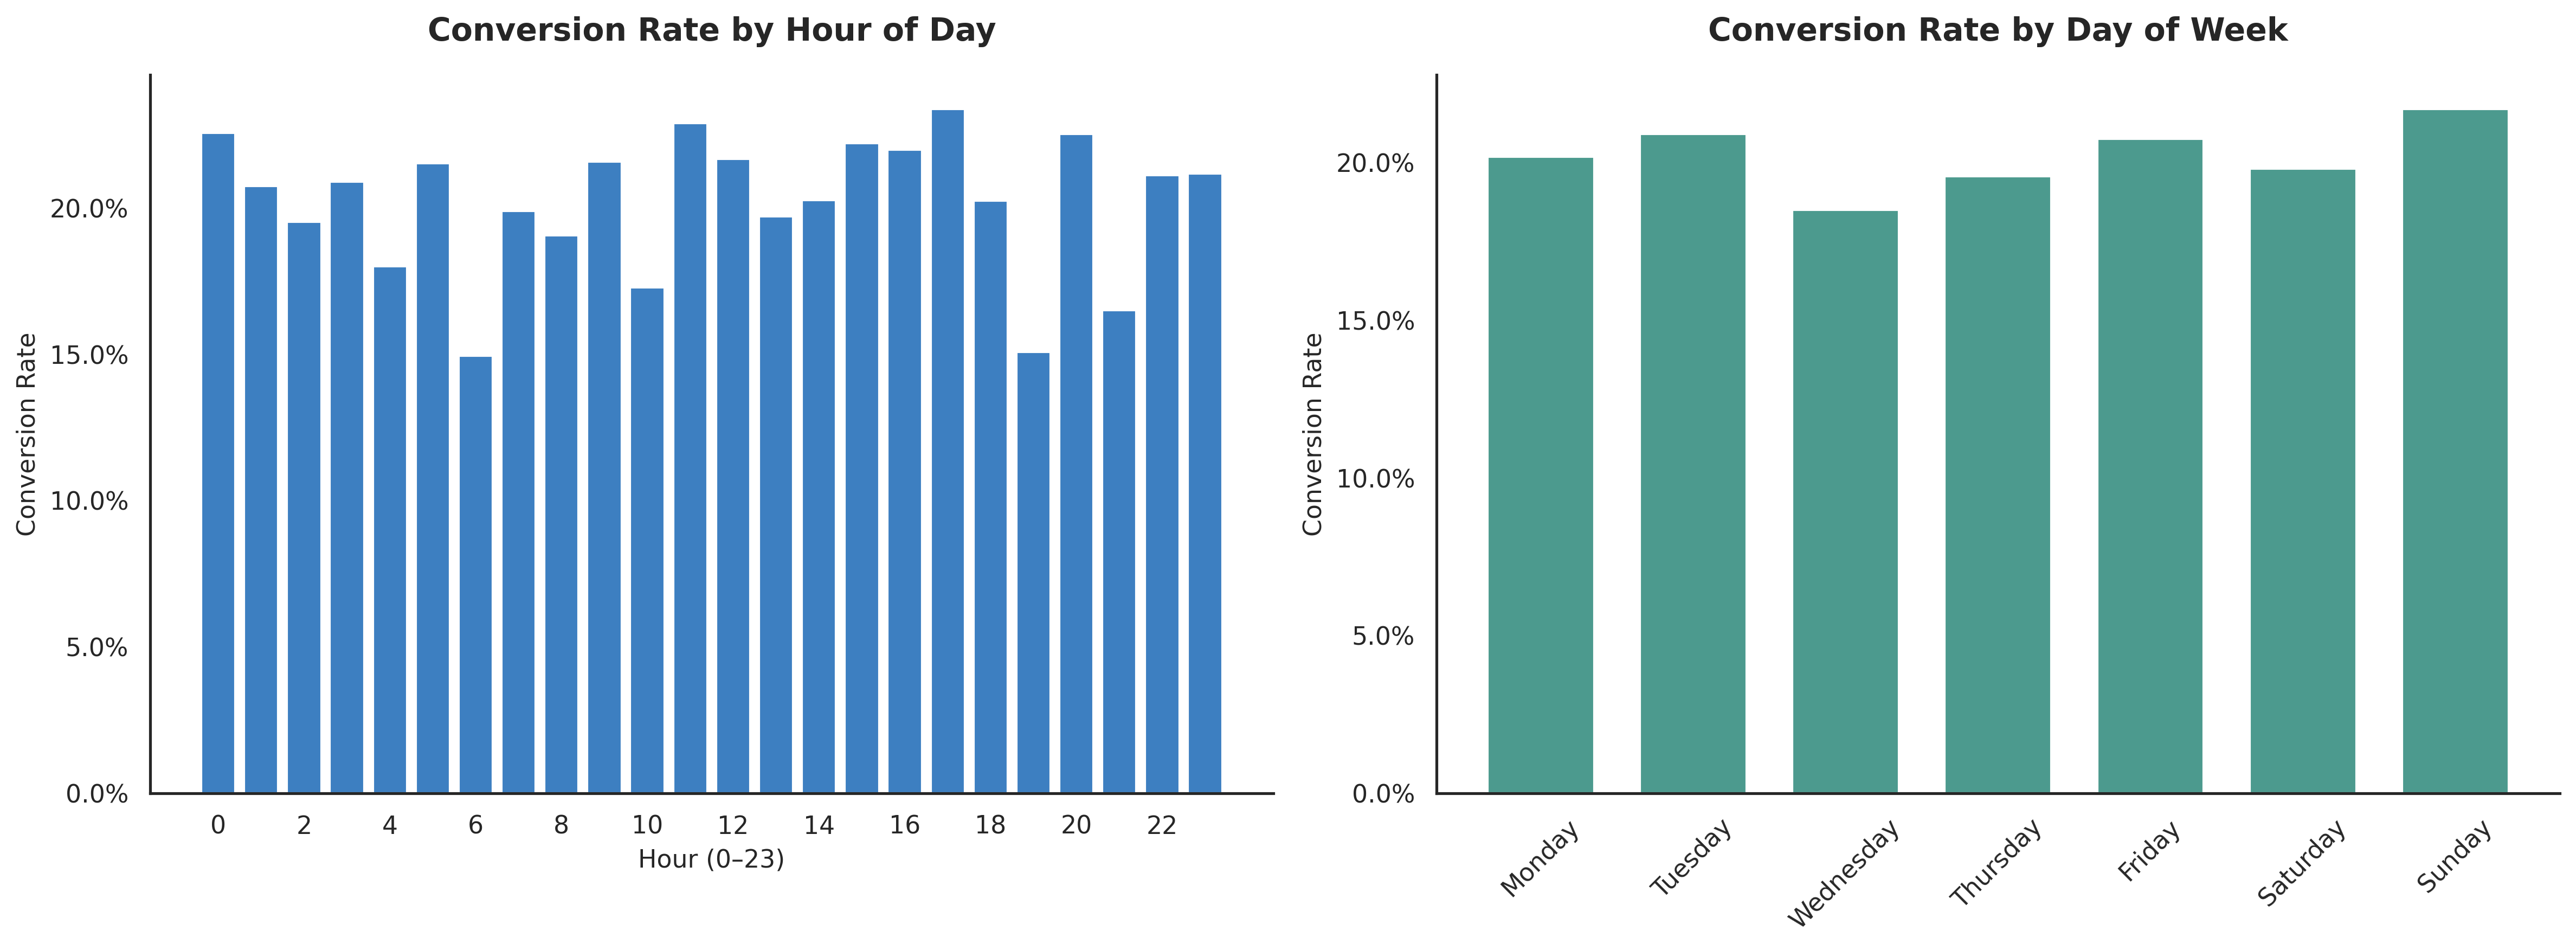

Conversion by Hour (Top 5):


,Hour,Purchased
17,17,23.39%
11,11,22.90%
0,0,22.57%
20,20,22.54%
15,15,22.22%



Conversion by Day:


,Day,Purchased
0,Monday,20.19%
1,Tuesday,20.91%
2,Wednesday,18.50%
3,Thursday,19.57%
4,Friday,20.76%
5,Saturday,19.81%
6,Sunday,21.72%


In [25]:
# Time-Based Conversion Analysis

# 1. Conversion by Hour of Day
session_hour = df.groupby('SessionID').agg(
    Hour=('HourOfDay', 'first'),
    Purchased=('Purchased', 'max')
).reset_index()

hour_conv = session_hour.groupby('Hour')['Purchased'].mean().reset_index()

# 2. Conversion by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

session_day = df.groupby('SessionID').agg(
    Day=('DayOfWeek', 'first'),
    Purchased=('Purchased', 'max')
).reset_index()

day_conv = session_day.groupby('Day')['Purchased'].mean().reindex(day_order).reset_index()
day_conv.columns = ['Day', 'Purchased']

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Hour chart
axes[0].bar(hour_conv['Hour'], hour_conv['Purchased'], color='#3D7FC1', width=0.8)
axes[0].set_title('Conversion Rate by Hour of Day', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Hour (0–23)', fontsize=11)
axes[0].set_ylabel('Conversion Rate', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_xticks(range(0, 24, 2))
sns.despine(ax=axes[0])

# Day chart
axes[1].bar(day_conv['Day'], day_conv['Purchased'], color='#4C9A8E', width=0.7)
axes[1].set_title('Conversion Rate by Day of Week', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Conversion Rate', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig('08_time_based_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("Conversion by Hour (Top 5):")
display(hour_conv.sort_values('Purchased', ascending=False).head().style.format({'Purchased': '{:.2%}'}))

print("\nConversion by Day:")
display(day_conv.style.format({'Purchased': '{:.2%}'}))